In [67]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv('/Users/ankushkumar/AI-Ml/Ai-Ml-Lab/bike_resale.csv')
df.head()

,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
0,B4543,TVS,25,14455.0,3,Excellent,40.6,NaN,Yes,41.6,No
1,B4392,TVS,43,26304.0,2,Good,51.2,1.0,Yes,24.1,No
2,B4235,Honda,38,6421.0,1,Good,65.0,NaN,No,48.2,No
3,B4319,Hero,14,6531.0,1,Good,NaN,NaN,Yes,58.7,No
4,B4284,TVS,115,80000.0,1,Good,61.8,0.0,No,12.0,Yes


In [69]:
# Q1.1 The website owner wants a short list. Show only the brand, km_driven and price_thousand of the first 10 bikes.

df_shortlist = df[['brand', 'km_driven', 'price_thousand']].head(10)
print(df_shortlist)

           brand  km_driven  price_thousand
0            TVS    14455.0            41.6
1            TVS    26304.0            24.1
2          Honda     6421.0            48.2
3           Hero     6531.0            58.7
4            TVS    80000.0            12.0
5  Royal Enfield     5524.0           153.7
6           Hero    22686.0            26.4
7         Yamaha    52795.0            12.0
8           Hero    78402.0            12.0
9            TVS    19605.0            54.8


In [70]:
# Q1.2 A customer only wants a Royal Enfield. Show all Royal Enfield bikes.

print(df[df['brand'] == 'Royal Enfield'])

    bike_id          brand  age_months  km_driven  owner_count  condition  \
5     B4533  Royal Enfield           5     5524.0            1       Good   
10    B4394  Royal Enfield          66    49224.0            1       Good   
40    B4328  Royal Enfield          16    11870.0            1       Fair   
75    B4499  Royal Enfield          25     5779.0            1       Good   
76    B4495  Royal Enfield          62    38138.0            1  Excellent   
83    B4493  Royal Enfield           5     4125.0            1  Excellent   
87    B4253  Royal Enfield          44    25018.0            2       Good   
98    B4217  Royal Enfield          93    63861.0            2       Fair   
100   B4303  Royal Enfield          66    44668.0            2       Good   
101   B4154  Royal Enfield          72    57056.0            2       Good   
102   B4458  Royal Enfield           5     2887.0            1       Good   
111   B4340  Royal Enfield          85        NaN            1       Good   

In [71]:
# Q1.3 How many Royal Enfield bikes are there in total?

print(df[df['brand'] == 'Royal Enfield'].shape[0])

48


In [72]:
# Q1.4 Another customer wants a bike in Excellent condition that costs less than 30 thousand. Show only the brand, condition and price_thousand of such bikes

print(df[(df['condition'] == 'Excellent') & (df['price_thousand'] < 30)][['brand', 'condition', 'price_thousand']])

      brand  condition  price_thousand
7    Yamaha  Excellent            12.0
8      Hero  Excellent            12.0
11    Honda  Excellent            12.0
26     Hero  Excellent            12.0
33    Bajaj  Excellent            17.4
..      ...        ...             ...
417    Hero  Excellent            12.0
418     TVS  Excellent            12.0
433    Hero  Excellent            26.7
434     TVS  Excellent            12.0
438   Bajaj  Excellent            12.0

[67 rows x 3 columns]


In [73]:
# Q1.5 Use .sort_values() to find the 5 cheapest bikes overall. Show only brand and price_thousand.

print(df.sort_values('price_thousand').head(5)[['brand', 'price_thousand']])


             brand  price_thousand
449          Bajaj            12.0
161            TVS            12.0
359            TVS            12.0
163  Royal Enfield            12.0
167         Yamaha            12.0


In [74]:
# Q2.1 Before sharing the file, the owner wants to know which columns have blank values, and how many in each.

print(df.isnull().sum())

bike_id            0
brand              0
age_months         0
km_driven          9
owner_count        0
condition          0
mileage_kmpl      26
service_count     74
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64


In [75]:
# Q2.2 Check whether the dataset has any repeated (duplicate) rows.

print(df.duplicated().sum())

0


In [76]:
# Q2.3 Fill the blanks in mileage_kmpl with the average mileage

df['mileage_kmpl'].fillna(df['mileage_kmpl'].mean(), inplace=True)


/var/folders/26/8dmzs5m57bl3f9r887j35wk80000gn/T/ipykernel_74449/2828845836.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['mileage_kmpl'].fillna(df['mileage_kmpl'].mean(), inplace=True)


0      40.600000
1      51.200000
2      65.000000
3      47.882075
4      61.800000
         ...    
445    53.900000
446    49.200000
447    48.500000
448    56.000000
449    51.100000
Name: mileage_kmpl, Length: 450, dtype: float64

In [77]:
# Q2.4 Remove the rows where km_driven is blank.

print(df[df['km_driven'].isnull()])

    bike_id          brand  age_months  km_driven  owner_count  condition  \
99    B4161            TVS          80        NaN            2  Excellent   
111   B4340  Royal Enfield          85        NaN            1       Good   
172   B4125            TVS          23        NaN            3       Fair   
208   B4423          Honda         115        NaN            1       Good   
262   B4306           Hero           5        NaN            2       Fair   
263   B4227         Yamaha          22        NaN            3       Fair   
382   B4260            TVS          27        NaN            1       Fair   
404   B4127          Honda         105        NaN            2       Good   
426   B4485          Bajaj          90        NaN            1       Good   

     mileage_kmpl  service_count insurance  price_thousand sold_in_week  
99           61.4            3.0        No            12.0           No  
111          53.1            3.0       Yes            47.5          Yes  
172    

In [78]:
# Q2.5 Print the shape of df after both cleaning steps above.

print(df.shape)


(450, 11)


In [79]:
# Q2.6 Run .isnull().sum() again to confirm the blanks you handled are gone.
print(df.isnull().sum())

bike_id            0
brand              0
age_months         0
km_driven          9
owner_count        0
condition          0
mileage_kmpl      26
service_count     74
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64


In [80]:
# Q3.1 Which brand sells for the most on average? Find the average price of each brand, from highest to lowest.

print(df.groupby('brand')['price_thousand'].mean().sort_values(ascending=False))


brand
Royal Enfield    67.981250
TVS              30.768182
Yamaha           30.734000
Honda            28.866304
Bajaj            27.135443
Hero             25.748387
Name: price_thousand, dtype: float64


In [81]:
# Q3.2 For each condition, show the average price and the number of bikes in one table using .agg().
print(df.groupby('condition')['price_thousand'].agg(['mean', 'count']))

                mean  count
condition                  
Excellent  36.161832    131
Fair       26.904545    110
Good       33.515311    209


In [82]:
# Q3.3 Which brand has the most bikes listed? Use .value_counts() on brand.
print(df['brand'].value_counts())

brand
Hero             93
Honda            92
TVS              88
Bajaj            79
Yamaha           50
Royal Enfield    48
Name: count, dtype: int64


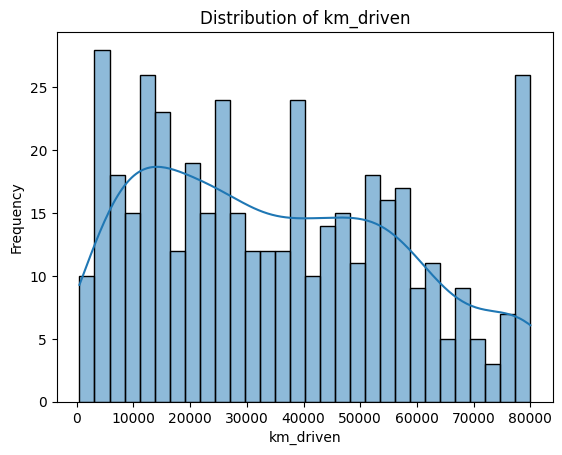

In [83]:
# Q4.1 How far have most bikes been driven? Draw the distribution of km_driven.

sns.histplot(df['km_driven'], bins=30, kde=True)
plt.title('Distribution of km_driven')
plt.xlabel('km_driven')
plt.ylabel('Frequency')
plt.show()
# print(df['km_driven'].describe())
# df['km_driven'].plot()

sold_in_week   No  Yes
brand                 
Bajaj          41   38
Hero           61   32
Honda          39   53
Royal Enfield  13   35
TVS            57   31
Yamaha         23   27


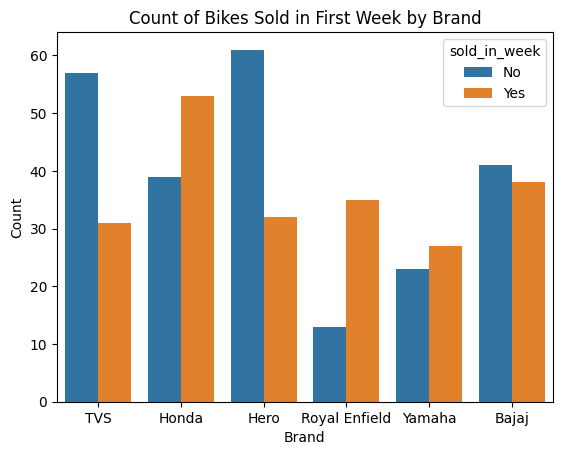

In [92]:
# Q4.2 For every brand, show how many bikes were sold in the first week and how many were not, using sns.countplot() with hue='sold_in_week'.

print(df.groupby('brand')['sold_in_week'].value_counts().unstack())
sns.countplot(data=df, x='brand', hue='sold_in_week')
plt.title('Count of Bikes Sold in First Week by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

Axes(0.125,0.11;0.775x0.77)


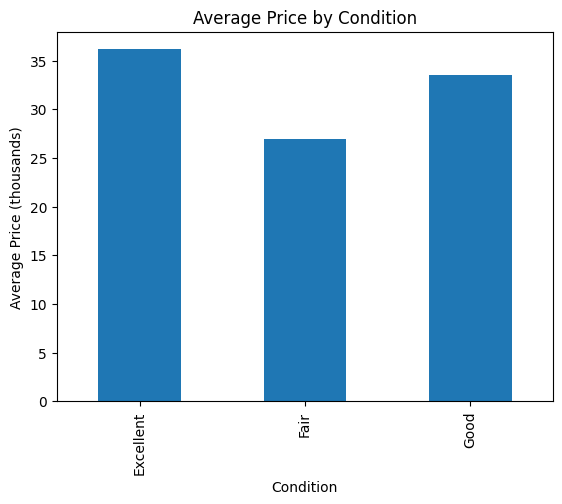

In [95]:
# Q4.3 A buyer says condition does not change the price. Draw one plot of price_thousand for each condition.

print(df.groupby('condition')['price_thousand'].mean().plot(kind='bar'))
plt.title('Average Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price (thousands)')
plt.show()

In [86]:
# Q4.4 Looking at the plot above — is the buyer right or wrong? Write your answer as a comment.

print("this is correct")

this is correct


Axes(0.125,0.11;0.775x0.77)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


Text(0.5, 1.0, 'Scatter Plot of Age vs Price Colored by Sold in Week')

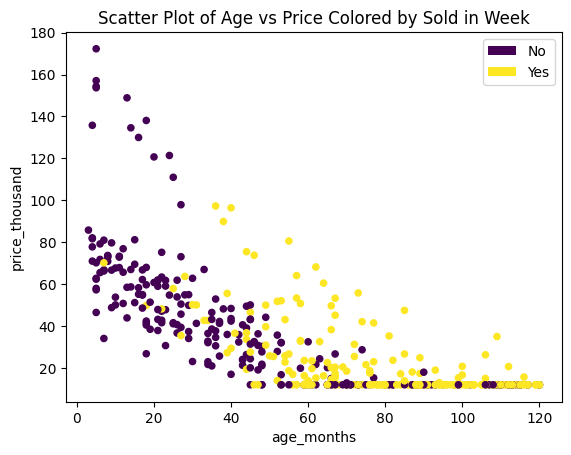

In [96]:
# Q4.5 Draw age_months against price_thousand, coloured by sold_in_week.
print(df.plot.scatter(x='age_months', y='price_thousand', c='sold_in_week', colormap='viridis'))
plt.title('Scatter Plot of Age vs Price Colored by Sold in Week')


In [88]:
# Q4.6 Based on that scatter plot — what happens to price as a bike gets older? Write your answer as a comment.
print("as the bike gets older, the price decreases")

as the bike gets older, the price decreases


Text(0.5, 1.0, 'Correlation Heatmap of Numeric Columns')

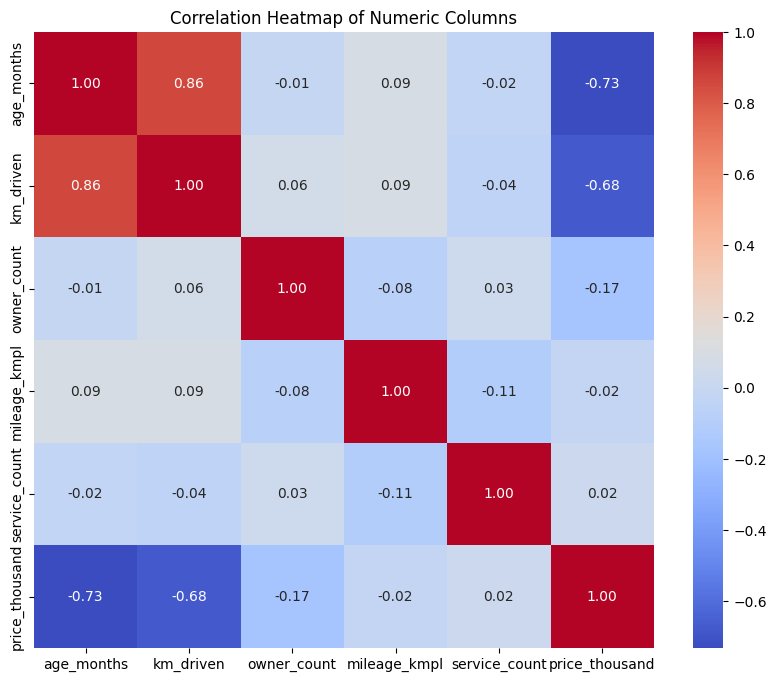

In [89]:
# Q4.7 Draw a heatmap of the correlation between the numeric columns.

df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Columns') 

In [90]:
# Q4.8 From the heatmap — which two columns move together the most? Write your answer as a comment.
print("price_thousand and age_months move together the most")

price_thousand and age_months move together the most
